In [12]:
import fast_matrix_market as fmm
from os.path import join
from scipy.sparse import coo,csc
import scipy.io as sio
import os
import socket
from collections import defaultdict
import numpy as np
import copy
import matplotlib.pyplot as plt

In [3]:
import taichi as ti
ti.init(arch=ti.cpu)

[Taichi] version 1.7.0, llvm 15.0.4, commit 2fd24490, linux, python 3.11.5
[Taichi] Starting on arch=x64


[I 03/18/24 11:29:24.084 621782] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


In [4]:
datamap = {}
if socket.gethostname() == 'chitu':
    datapath = "/home/hongy0a/graphclustering/dataset"
else:
    datapath = "/global/cfs/cdirs/m1982/yuxihong/spgemm1ddataset"
datamap['vir'] = join(datapath,"vir_vs_vir_30_50length_propermm.mtx")
print(datamap['vir'])

/home/hongy0a/graphclustering/dataset/vir_vs_vir_30_50length_propermm.mtx


In [5]:
virdata = fmm.mmread(datamap['vir']).tocsc()

In [6]:
partfile = join("/home/hongy0a/graphclustering/CombBLAS_YuxiPrivate/build", "vir_none.graph.part.16")
resultvec = []
nprocs = 16
with open(partfile, 'r') as f:
    while 1:
        line = f.readline()
        if not line:
            break
        resultvec.append(int(line))

In [7]:
blocksizevec = []
groupmap = defaultdict(list)
for i in range(len(resultvec)):
    groupmap[resultvec[i]].append(i)
sforder = []
for i in range(nprocs):
    blocksizevec.append(len(groupmap[i]))
    for x in groupmap[i]:
        sforder.append(x)
virdata = virdata[sforder,:]
virdata = virdata[:,sforder]

print(blocksizevec)
blocksizevec = np.array(blocksizevec)
blocksizeprefix = list(np.cumsum(blocksizevec))
blocksizeprefix.insert(0,0)
blocksizeprefix = np.array(blocksizeprefix)
print(blocksizeprefix)

[13733, 13734, 13730, 13733, 13732, 13731, 13725, 13738, 13731, 13735, 13728, 13736, 13731, 13728, 13733, 13737]
[     0  13733  27467  41197  54930  68662  82393  96118 109856 123587
 137322 151050 164786 178517 192245 205978 219715]


In [8]:
nnzstats = np.zeros((nprocs,nprocs),dtype=np.int64)

In [9]:
blocksizeprefix

array([     0,  13733,  27467,  41197,  54930,  68662,  82393,  96118,
       109856, 123587, 137322, 151050, 164786, 178517, 192245, 205978,
       219715])

In [10]:
for jidx in range(len(virdata.indptr)-1):
    jstart = virdata.indptr[jidx]
    jend = virdata.indptr[jidx+1]
    if jend - jstart == 0:
        continue
    else:
        # print(">")
        cowner = 0
        while cowner < nprocs and blocksizeprefix[cowner] <= jidx:
            cowner += 1
        cowner -= 1
        for ridx in virdata.indices[jstart:jend]:
            rowner = 0
            while rowner < nprocs and blocksizeprefix[rowner] <= ridx:
                rowner += 1
            rowner -= 1
            nnzstats[cowner,rowner] += 1


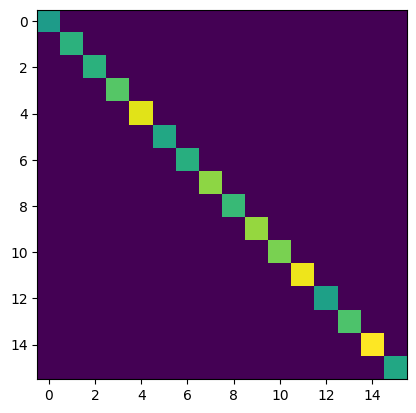

In [13]:
plt.imshow(nnzstats)